Instructions:

In this lesson you were shown how to build a model using both Linear and Polynomial Regression. Using this knowledge, find a dataset or use one of Scikit-learn's built-in sets to build a fresh model. Explain in your notebook why you chose the technique you did, and demonstrate your model's accuracy. If it is not accurate, explain why.

In [34]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from matplotlib import pyplot as plt


# Load the California housing dataset
"""
California Housing Dataset

Features:
    MedInc median income in block group

    HouseAge median house age in block group

    AveRooms average number of rooms per household

    AveBedrms average number of bedrooms per household

    Population block group population

    AveOccup average number of household members

    Latitude block group latitude

    Longitude block group longitude

Target:
    MedHouseVal median house value for California districts
"""

data = fetch_california_housing(as_frame=True)
df = data.frame


Find the most correlated features with the target to ask the right question. 

In [35]:
for feature in data.feature_names:
    corr = df[feature].corr(df[data.target_names[0]])
    print(f"Correlation between {feature} and {data.target_names[0]}: {corr:.4f}")


Correlation between MedInc and MedHouseVal: 0.6881
Correlation between HouseAge and MedHouseVal: 0.1056
Correlation between AveRooms and MedHouseVal: 0.1519
Correlation between AveBedrms and MedHouseVal: -0.0467
Correlation between Population and MedHouseVal: -0.0246
Correlation between AveOccup and MedHouseVal: -0.0237
Correlation between Latitude and MedHouseVal: -0.1442
Correlation between Longitude and MedHouseVal: -0.0460


Looks like the MedInc is highly correlated with the MedHouseVal. 

Question: Can I predict the House Value with the Median Income? 

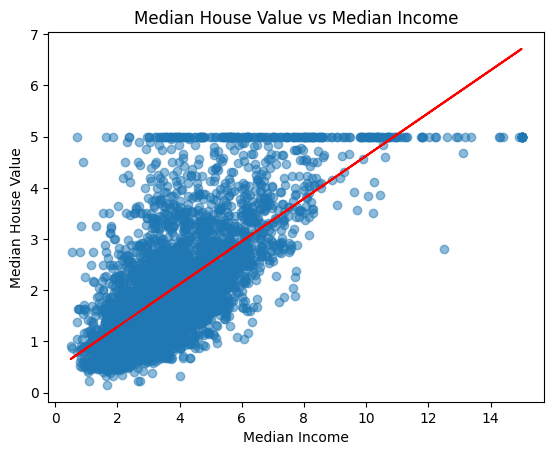

In [36]:
x = df[["MedInc"]]
y = df["MedHouseVal"]


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2) 

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)


plt.scatter(x_test['MedInc'], y_test, alpha=0.5)
plt.plot(x_test['MedInc'], y_pred, color='red')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Median House Value vs Median Income')
plt.show()

See how accurate our model is.

In [38]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Squared Error: 0.7034
Root Mean Squared Error: 0.8387
R^2 Score: 0.4809


I chose linear regression for this dataset because the target is a numeric value and the features are numeric as well. Also, by plotting the x,y you can see a linear relationship there.